In [38]:
def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

In [39]:
# performance=readInputAsArray('/Users/yibeijia/Downloads/data/train_model1_out')
performance=readInputAsArray('/Users/yibeijia/Downloads/data/train_model2_out')
e = 0
E = []
avgs=[]
start = 1
total = 0
for i in performance:

    i = i.split()
#     print( i[0])
    if start == 1:
        val = float(i[7][:6])
#         print(val)
        total += val
        start = 0
    
    # New Epoch
    elif i[0] == '1/1944':
        avg = total / 1944;
        avgs = avgs + [avg]
        total = 0
        e+=1
        E+=[e]
#         print("epoch", e)
#         print(avg)
        
    else:
        val = float(i[7][:6])
#         print(val)
        total += val
# The last epoch
avg = total / 1944;
avgs = avgs + [avg]
e+=1
E+=[e]
print("epoch", e)
print(avg)
print (avgs)
print (len(avgs))

epoch 22
0.019877777777778008
[0.2925277263374496, 0.2260201131687239, 0.21197613168724352, 0.1960110082304517, 0.17993960905349904, 0.16702232510287982, 0.15505288065843503, 0.14094974279835482, 0.13019413580246986, 0.11770735596707661, 0.10538461934156337, 0.09476316872427872, 0.07870817901234586, 0.06679706790123523, 0.05426347736625504, 0.04656399176954777, 0.03874182098765482, 0.03527896090534999, 0.028457407407407397, 0.025321090534979118, 0.022608950617284216, 0.019877777777778008]
22


In [42]:
# performance=readInputAsArray('/Users/yibeijia/Downloads/data/test_out3')
performance=readInputAsArray('/Users/yibeijia/Downloads/data/val_loss_model2')
e = 0
E = []
avgs_val=[]
for i in performance:
    i = i.split()
    avgs_val += [float(i[1])]

print (avgs_val)
print (len(avgs_val))

[0.2218, 0.2114, 0.2023, 0.1868, 0.2041, 0.1847, 0.1449, 0.1436, 0.1557, 0.1462, 0.1462, 0.1158, 0.1286, 0.1291, 0.1364, 0.1362, 0.1922, 0.157, 0.1695, 0.1786, 0.1745, 0.2117]
22


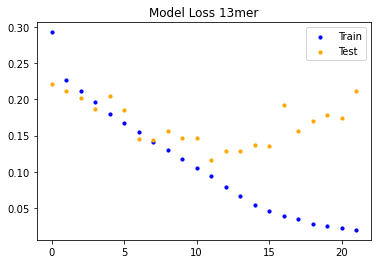

In [44]:
import matplotlib.pyplot as plt

# plt.scatter(range((len(avgs_val))), avgs[1:], s=10, color='blue', label='Train')
plt.scatter(range((len(avgs_val))), avgs, s=10, color='blue', label='Train')
plt.scatter(range(len(avgs_val)), avgs_val, s=10, color='orange', label='Test')
plt.legend()
plt.title('Model Loss 13mer')
plt.savefig("ModelLoss_13mer.jpg")

In [46]:
avgs_val.index(min(avgs_val))

11

In [30]:
test_out = '/Users/yibeijia/Downloads/data/test_copy.out'
# test_out = '/Users/yibeijia/Downloads/data/test_model2.out'
test=readInputAsArray(test_out)        

In [23]:
true = []
pred = []

for i in test:
    line = i.split()
    for k in line:
        score = k.split("=")
        if score[0]=="TrueLabel":
#             print(score[1][1])
            true += [int(score[1][1])]
        if score[0]=="Predicted":
#             print(score[0][1])
            if (float(score[1][1:len(score[1])-1]) > 0.5):
                pred += [1]
            else:
                pred += [0]  

In [26]:
pred[:5]

[1, 0, 1, 0, 1]

In [25]:
true[:5]

[1, 0, 1, 0, 1]

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(true, pred)

0.9467868223609738

In [28]:
from sklearn.metrics import precision_score
precision_score(true, pred)

0.9349932270180408

In [29]:
from sklearn.metrics import recall_score
recall_score(true, pred)

0.9475915089320954